=== 실험 08 확장. OP-AMP 사인/사각파 적분 및 미분 회로 ===
※ 모든 값은 코드 내부에서 자동 적용됩니다.

--- (1) 미분 회로 출력 ---


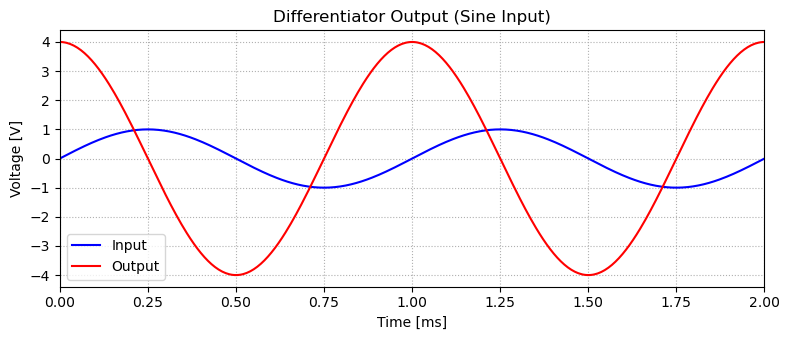

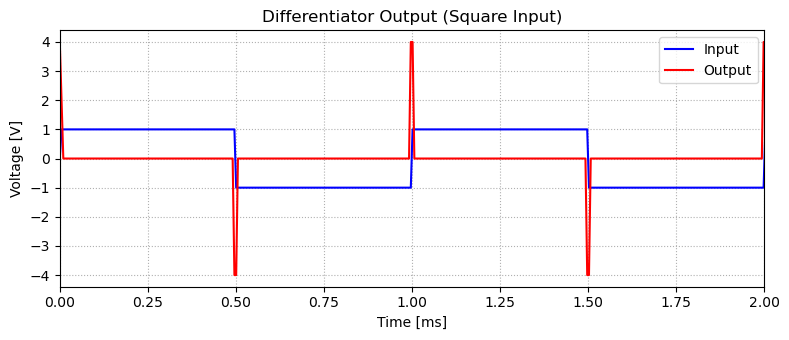

--- (2) 적분 회로 출력 ---


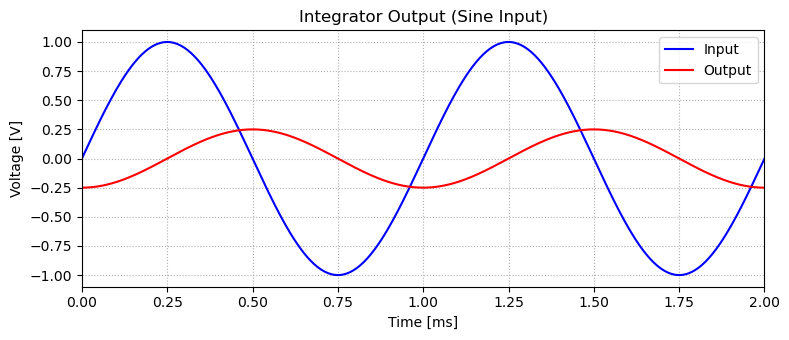

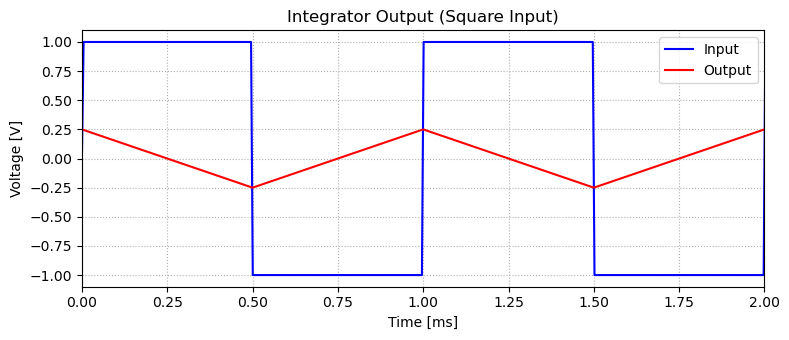

In [2]:
# ============================================
# 실험 08 확장. OP-AMP 사인/사각파 적분 및 미분 회로
# (입력 없이 자동 실행)
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 기본 설정
# ===============================
fs = 200000        # 샘플링 주파수
f = 1000           # 1kHz
duration = 0.004   # 4ms
t = np.linspace(0, duration, int(fs * duration))

print("=== 실험 08 확장. OP-AMP 사인/사각파 적분 및 미분 회로 ===")
print("※ 모든 값은 코드 내부에서 자동 적용됩니다.\n")

# ===============================
# 자동 설정 값
# ===============================
Vin_amp = 1.0        # 입력 peak
diff_peak = 4.0      # 미분 회로 출력 peak
int_peak = 0.25      # 적분 회로 출력 peak

# ===============================
# (1) 입력 파형 생성
# ===============================

# 사인파
Vin_sin = Vin_amp * np.sin(2 * np.pi * f * t)

# 사각파
Vin_sq = Vin_amp * np.sign(np.sin(2 * np.pi * f * t))

# ===============================
# (2) 미분 회로 출력
# ===============================

# sin → cos
Vout_diff_sin = diff_peak * np.cos(2 * np.pi * f * t)

# square → spike (미분하면 엣지에서 큰 값)
Vout_diff_sq = np.gradient(Vin_sq) * fs   # dt = 1/fs 이므로 dV/dt = gradient * fs
Vout_diff_sq = Vout_diff_sq / np.max(np.abs(Vout_diff_sq)) * diff_peak

# ===============================
# (3) 적분 회로 출력
# ===============================

# sin → -cos
Vout_int_sin = -int_peak * np.cos(2 * np.pi * f * t)

# square → triangle
# 삼각파: sin을 integration해서도 되지만 여기서는 원형유지용 직접 계산
phase = (t * f) % 1.0
triangle_norm = 2 * np.abs(2 * phase - 1) - 1
Vout_int_sq = triangle_norm * int_peak

# ===============================
# 그래프 함수
# ===============================
def draw(time, vin, vout, title):
    plt.figure(figsize=(8, 3.5))
    plt.plot(time * 1000, vin, label="Input", color='blue')
    plt.plot(time * 1000, vout, label="Output", color='red')
    plt.title(title)
    plt.xlabel("Time [ms]")
    plt.ylabel("Voltage [V]")
    plt.grid(True, linestyle=':')
    plt.xlim(0, 2)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===============================
# (A) 미분 회로 그래프
# ===============================
print("--- (1) 미분 회로 출력 ---")
draw(t, Vin_sin, Vout_diff_sin, "Differentiator Output (Sine Input)")
draw(t, Vin_sq,  Vout_diff_sq,  "Differentiator Output (Square Input)")

# ===============================
# (B) 적분 회로 그래프
# ===============================
print("--- (2) 적분 회로 출력 ---")
draw(t, Vin_sin, Vout_int_sin, "Integrator Output (Sine Input)")
draw(t, Vin_sq,  Vout_int_sq,  "Integrator Output (Square Input)")
